**Kaggle API call to get raw data (credit card dataset)**

In [11]:
import boto3
from botocore.exceptions import ClientError


def get_secret():

    secret_name = "my-kaggle-secret"
    region_name = "eu-south-2"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        # For a list of exceptions thrown, see
        # https://docs.aws.amazon.com/secretsmanager/latest/apireference/API_GetSecretValue.html
        raise e

    secret = get_secret_value_response['SecretString']
    return secret

In [12]:
secret=get_secret()

In [14]:
creds = json.loads(secret)
os.environ['KAGGLE_USERNAME'] = next(iter(creds))
os.environ['KAGGLE_KEY'] = next(iter(creds.values()))

In [15]:
!kaggle datasets download -d mlg-ulb/creditcardfraud --unzip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100%|██████████████████████████████████████| 66.0M/66.0M [00:02<00:00, 26.0MB/s]



**Uploading dataset to S3**

In [17]:
sess = sagemaker.Session()

In [18]:
uri = sess.upload_data(path='creditcard.csv', bucket=sess.default_bucket(), key_prefix='fraud-project')
print(f"Data is uploaded to S3: {uri}")

Data is uploaded to S3: s3://sagemaker-eu-south-2-750004260444/fraud-project/creditcard.csv


**Preprocessing raw data from S3** - launching SageMaker processing job processing.py

In [16]:
import sagemaker
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

#  Setup session and role
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
bucket = sess.default_bucket() 

#  Define the Processor
sklearn_processor = SKLearnProcessor(
    framework_version="1.2-1",
    role=role,
    instance_type="ml.t3.medium",
    instance_count=1
)

#  Run the Job
sklearn_processor.run(
    code="scripts/preprocessing.py",
    inputs=[
        ProcessingInput(
            source=f"s3://sagemaker-eu-south-2-750004260444/fraud-project/creditcard.csv",
            destination="/opt/ml/processing/input"
        )
    ],
    outputs=[
        ProcessingOutput(output_name="train_data", source="/opt/ml/processing/output/train"),
        ProcessingOutput(output_name="test_data", source="/opt/ml/processing/output/test"),
        ProcessingOutput(output_name='preprocessing_meta', source='/opt/ml/processing/output')
    ]
)

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker:Creating processing-job with name sagemaker-scikit-learn-2026-04-24-13-14-18-665


..............Memory usage of dataframe is 67.36 MB
Memory usage after optimization is: 32.87 MB
Decreased by 51.2%
Successfully processed data and saved to output!



**Training job SageMaker** - launching training.py with already found previously optimized hyperparameters (see notebook `hyperparam_search.ipynb`)

In [11]:
from sagemaker.sklearn.estimator import SKLearn

# Paths where the processing job saved the data
train_s3_uri = "s3://sagemaker-eu-south-2-750004260444/sagemaker-scikit-learn-2026-04-23-11-48-21-287/output/train_data"
test_s3_uri = "s3://sagemaker-eu-south-2-750004260444/sagemaker-scikit-learn-2026-04-23-11-48-21-287/output/test_data"

sklearn_estimator = SKLearn(
    entry_point='train.py',
    source_dir='scripts',      #  This folder contais train.py and requirements.txt
    role=sagemaker.get_execution_role(),
    instance_count=1,
    instance_type='ml.m5.large', 
    framework_version='1.2-1',
    py_version='py3',
)

# Starting the job and creating the Training Job in the console
sklearn_estimator.fit({
    'train': train_s3_uri,
    'test': test_s3_uri
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: sagemaker-scikit-learn-2026-04-24-09-23-00-990


2026-04-24 09:23:01 Starting - Starting the training job.........
2026-04-24 09:24:32 Downloading - Downloading input data...
2026-04-24 09:25:03 Downloading - Downloading the training image......
2026-04-24 09:26:03 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-04-24 09:26:06,354 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2026-04-24 09:26:06,358 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-04-24 09:26:06,361 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-04-24 09:26:06,377 sagemaker_sklearn_co

**Download training job results to S3 - model and outputs**. Showing model results.

Files extracted to the 'results' folder!


/tmp/ipykernel_301/268487450.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="results")
/tmp/ipykernel_301/268487450.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="results")


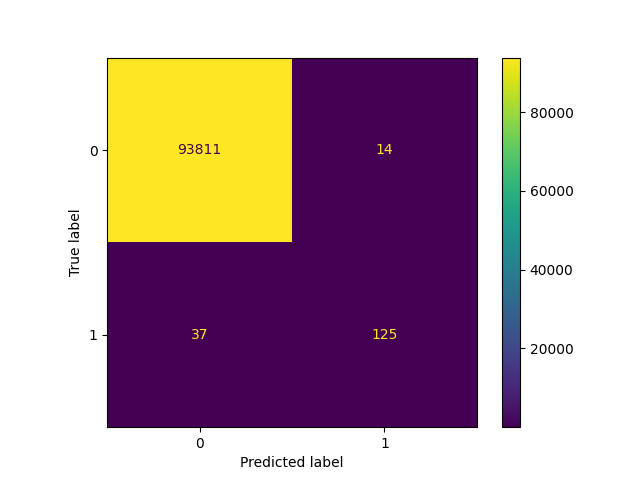

In [13]:
from sagemaker.s3 import S3Downloader
import tarfile
import os
from IPython.display import Image

# Setup paths
# Grab the job name from the estimator automatically
job_name = sklearn_estimator.latest_training_job.name

model_s3_uri = f"s3://sagemaker-eu-south-2-750004260444/{job_name}/output/model.tar.gz"
output_s3_uri = f"s3://sagemaker-eu-south-2-750004260444/{job_name}/output/output.tar.gz"

# Download to the current directory
print("Downloading from S3...")
S3Downloader.download(model_s3_uri, ".")
S3Downloader.download(output_s3_uri, ".")

#  Extract to a dedicated 'results' folder
os.makedirs("results", exist_ok=True)

with tarfile.open("model.tar.gz", "r:gz") as tar:
    tar.extractall(path="results")
    
with tarfile.open("output.tar.gz", "r:gz") as tar:
    tar.extractall(path="results")

print("Files extracted to the 'results' folder!")

#  Show the Confusion Matrix
display(Image(filename='results/confusion_matrix.png'))